### Exercises
Tasks:
1. Perform an exploratory data analysis on the Cleveland heart disease dataset described above.
You can reuse your code from the in-class project. Label the analysis with respect to the data
analysis steps in the lecture (Initial Data Analysis 1-7)
2. Train at least three types of classifiers to diagnose heart disease based on the available data and
compare them visually in a grouped bar chart with regard to accuracy, sensitivity, and specificity.
Create a confusion matrix for each classifier and plot them as a heatmap.
3. Repeat the steps of the previous task, using as class labels only “heart disease vs. no heart
disease”
. Analyze the implications of this change. Does it make sense?
4. Create and plot ROC curves for your classifiers (2-class problem only).

**Data Analysis:**

**1-BIG PICTURE- TOPIC, SOURCE**

**TOPIC**: THE PRESENCE OF HEART DISESES IN THE PATIENTS. DATASET CONTAINS 76 ATTRIBUTES. UCI Machine Learning Repository[](https://archive.ics.uci.edu/dataset/45/heart+disease).

**SOURCE**:PATIENTS UNDERGOING ANGIOGRAPHY AT Cleveland Clinic in Cleveland, Ohio, Hungarian Institute of Cardiology in Budapest, Hungary, Veterans Administration Medical Center in Long Beach, California, and University Hospitals in Zurich and Basel, Switzerland.

**QUESTION**: Understanding the features and their relation to make prediction related heart diseases

In [2]:
from google.colab import files
files.upload()



Saving processedWithHeader.cleveland.data to processedWithHeader.cleveland.data


{'processedWithHeader.cleveland.data': b'age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,goal\n63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0\n67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2\n67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1\n37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0\n41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0\n56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0\n62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3\n57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0\n63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2\n53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1\n57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0\n56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,0\n56.0,1.0,3.0,130.0,256.0,1.0,2.0,142.0,1.0,0.6,2.0,1.0,6.0,2\n44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,0\n52.0,1.0,3.0

**2- Reading and importing the file for the code to read**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
data = pd.read_csv('processedWithHeader.cleveland.data')

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,goal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**3-Size and Structure**

In [4]:
print(data.shape)

(303, 14)


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  goal      303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,goal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


**4-Missing data and further dataset cleaning**

In [7]:
print(data.isnull().sum())

# Replace '?' with NaN and convert 'ca' and 'thal' to numeric
data['ca'] = data['ca'].replace('?', np.nan).astype(float)
data['thal'] = data['thal'].replace('?', np.nan).astype(float)

# Impute missing values with the mean
data['ca'].fillna(data['ca'].mean(), inplace=True)
data['thal'].fillna(data['thal'].mean(), inplace=True)

data['sex_definition']=np.where(data["sex"]==1, 'Male','Female')
#added a new column which gives male and female tags to data for better visibility


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
goal        0
dtype: int64


/tmp/ipython-input-2763659892.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['ca'].fillna(data['ca'].mean(), inplace=True)
/tmp/ipython-input-2763659892.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

**5-Overview of the data**

Distinct age [63. 67. 37. 41. 56. 62. 57. 53. 44. 52. 48. 54. 49. 64. 58. 60. 50. 66.
 43. 40. 69. 59. 42. 55. 61. 65. 71. 51. 46. 45. 39. 68. 47. 34. 35. 29.
 70. 77. 38. 74. 76.]
Distinct sex [1. 0.]
Distinct sex ['Male' 'Female']


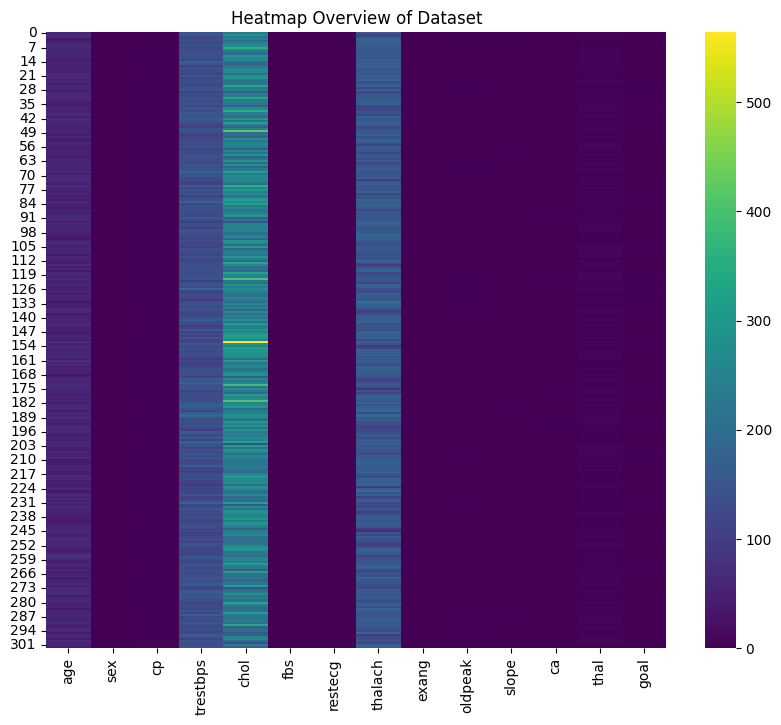

In [8]:
import matplotlib.pyplot as plt

print(f'Distinct age {data['age'].unique()}')
print(f'Distinct sex {data['sex'].unique()}')

print(f'Distinct sex {data['sex_definition'].unique()}')

# age 1: male 0: female
numeric_data=data.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data, cmap='viridis')
plt.title('Heatmap Overview of Dataset')
plt.show()

In [9]:
print(data.groupby(['age', 'sex_definition']).size())

age   sex_definition
29.0  Male              1
34.0  Female            1
      Male              1
35.0  Female            1
      Male              3
                       ..
70.0  Male              4
71.0  Female            3
74.0  Female            1
76.0  Female            1
77.0  Male              1
Length: 73, dtype: int64


**6-Understanding single variables - univariate
analysis: categorical data**

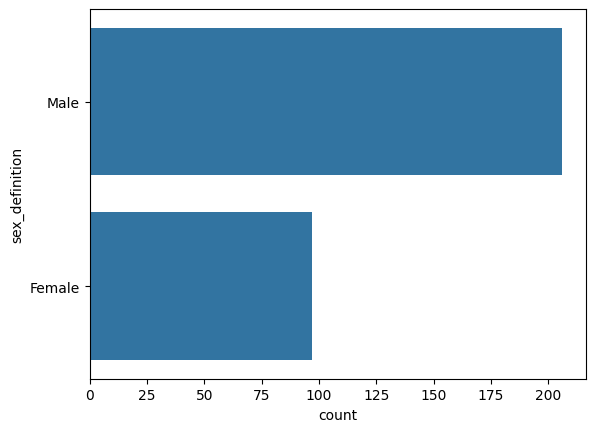

In [10]:
import seaborn as sns
sns.countplot(data['sex_definition'],label="Count")
#This chart the count of records for each type of fruits. With counts on x-axis and the fruits on the y-axis
plt.show()

6- **Understanding single variables - univariate
analysis: numerical data**

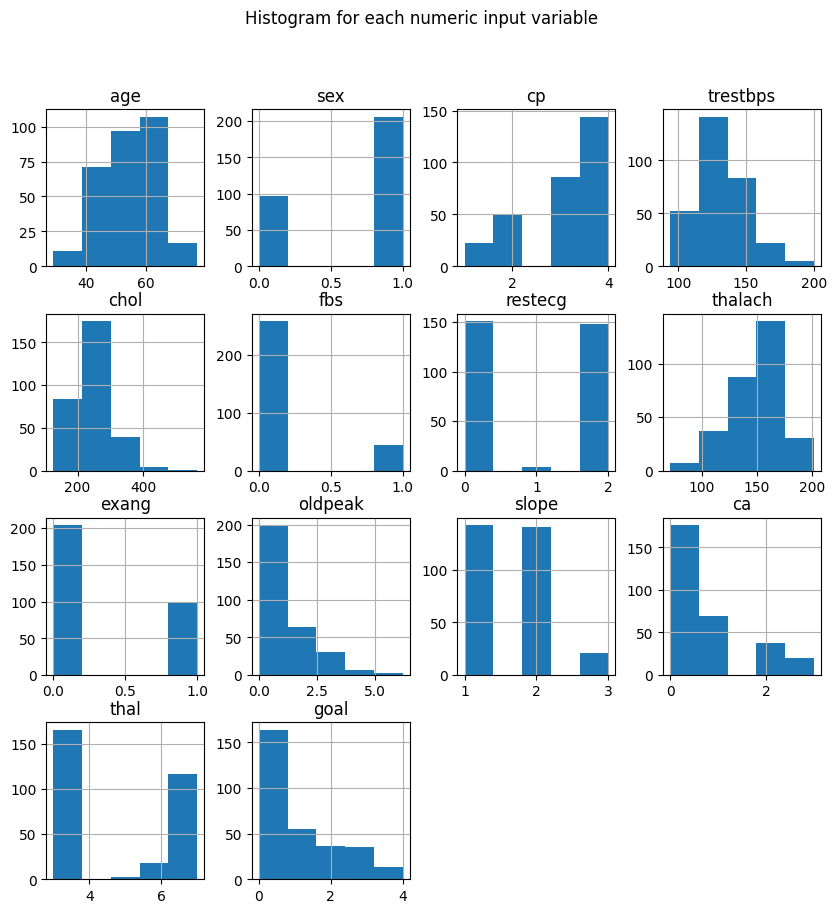

In [11]:
import matplotlib.pyplot as plt
numeric_data = data.select_dtypes(include=['number'])
numeric_data.hist(bins=5, figsize=(10, 10))
plt.suptitle("Histogram for each numeric input variable")
plt.savefig('data_hist')
# histogram showing 4 featurs like mass, width, height and color score on y axis with showing the counts of fruits on the x-axis
plt.show()


**6- Further comments for univariate analysis**

There are some outliers in the features like trestbps, cp, chol, oldpeak and fbs

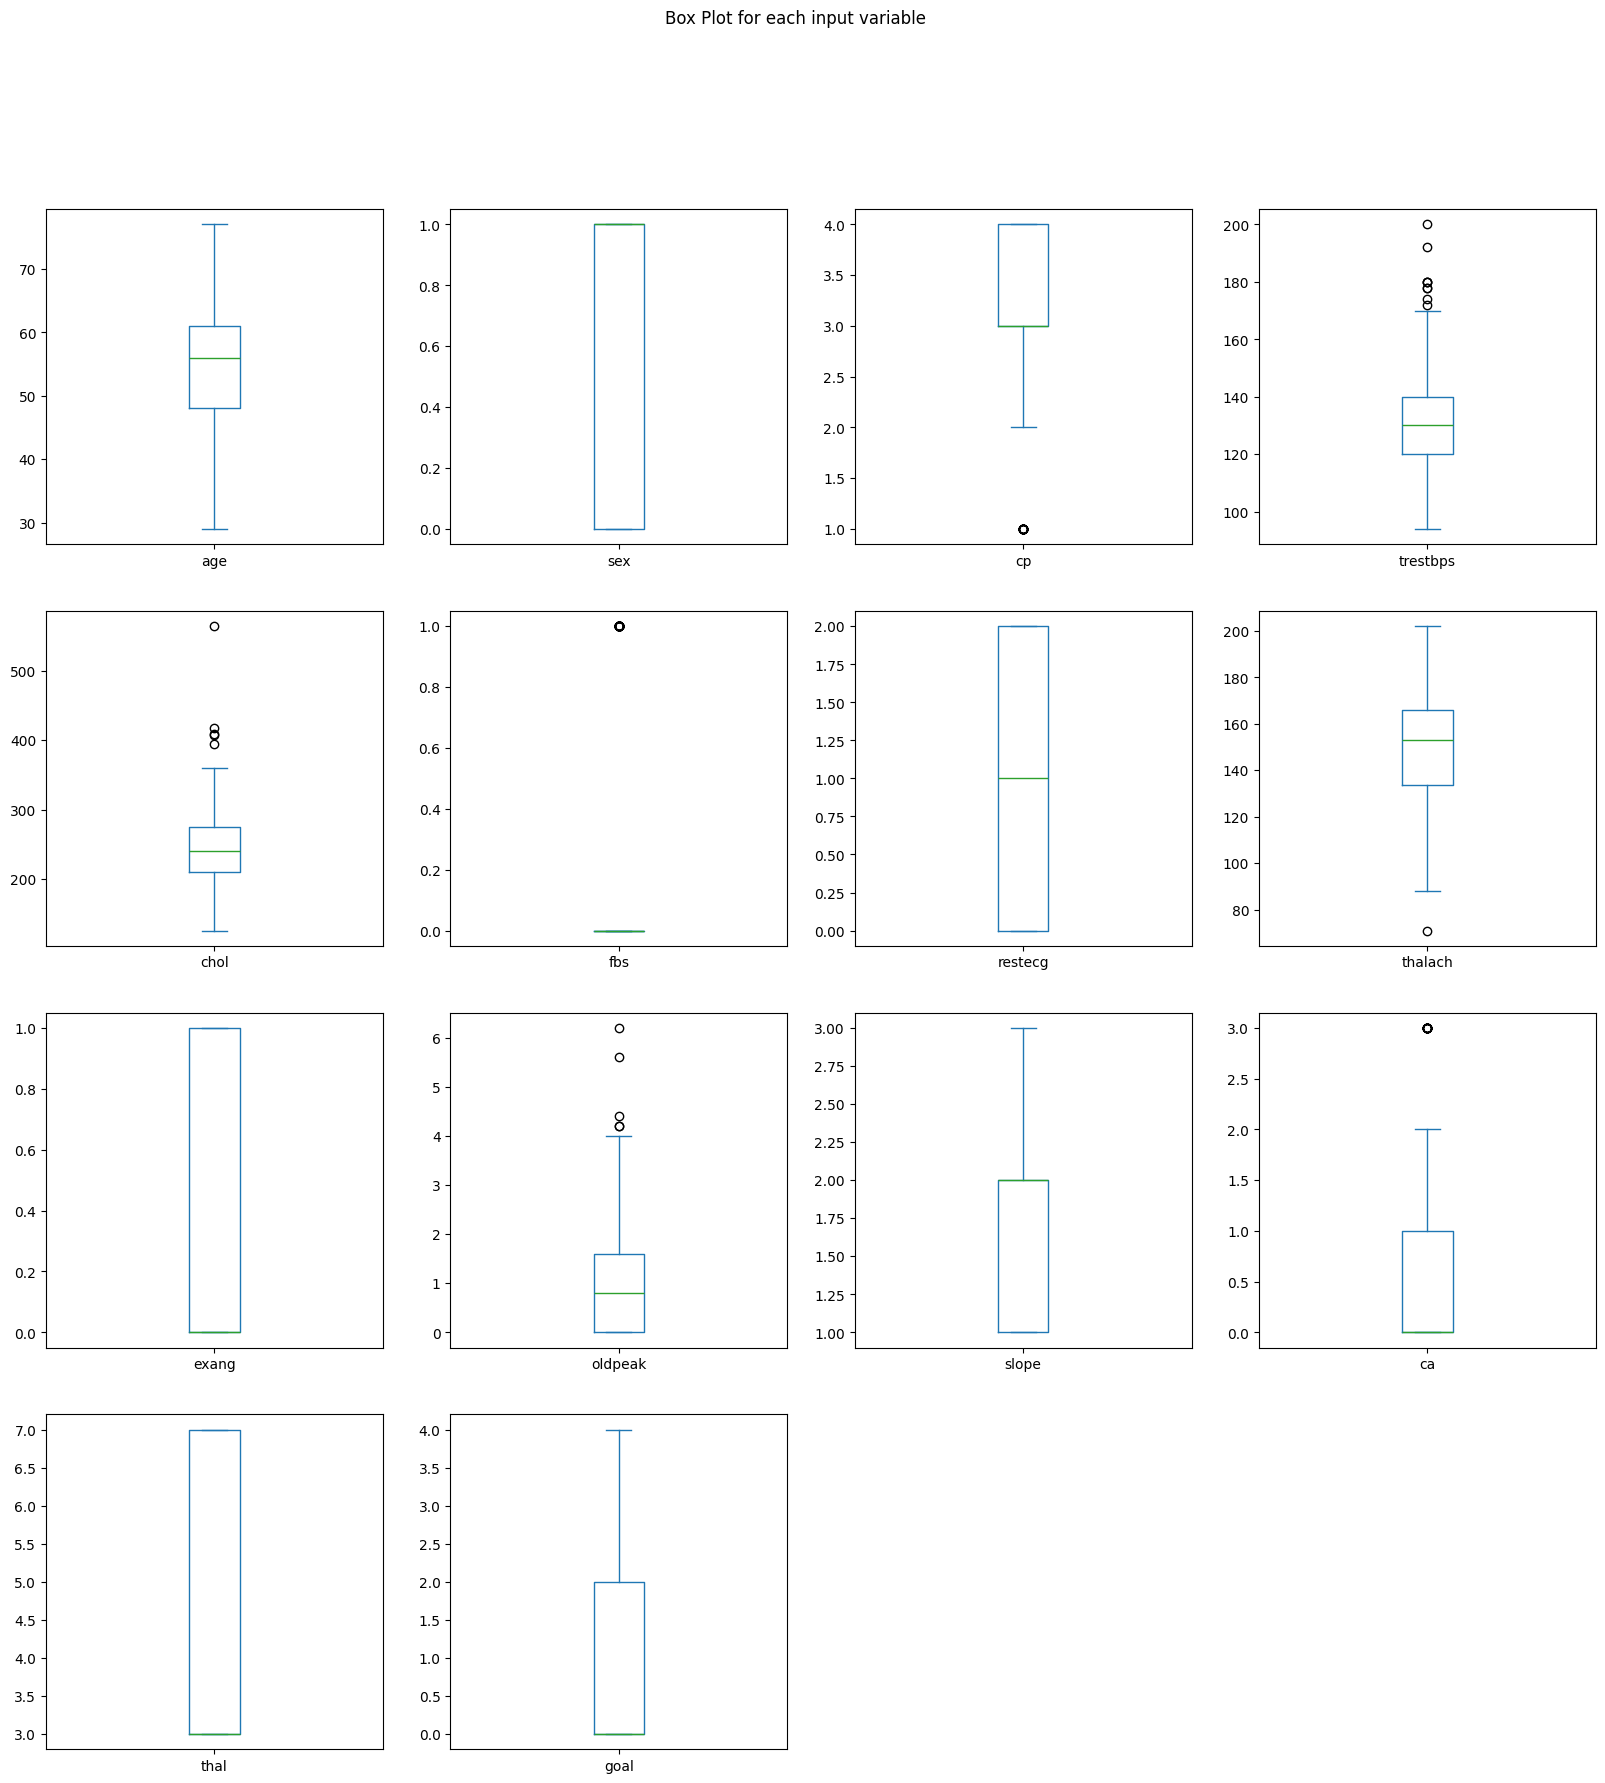

In [12]:
data.drop('sex_definition',axis=1).plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(20,20), title='Box Plot for each input variable')
plt.savefig('data_outliers_detection')
# this plot displays the distribution, central tendency (median), spread (Interquartile Range), and potential outliers for the key numeric input variables, such as mass, width, height, and color_score.
plt.show()
#there are some outliers in the features like trestbps, cp, chol, oldpeak and fbs

**7-Understanding relationships between
variables**

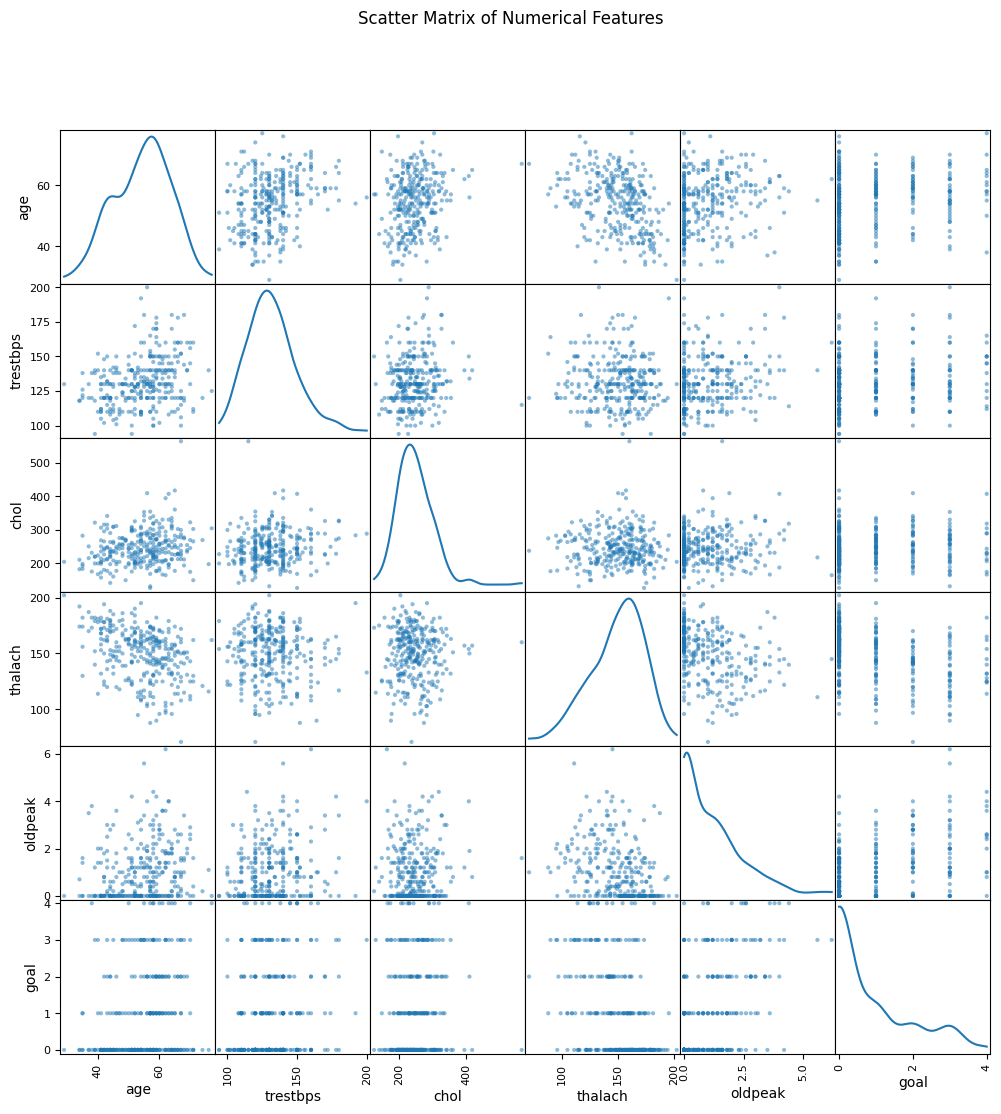

In [13]:
from pandas.plotting import scatter_matrix
from matplotlib import cm
feature_names = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak','goal']
scatter_matrix(data[feature_names], figsize=(12,12), diagonal='kde')
plt.suptitle('Scatter Matrix of Numerical Features')
plt.show()

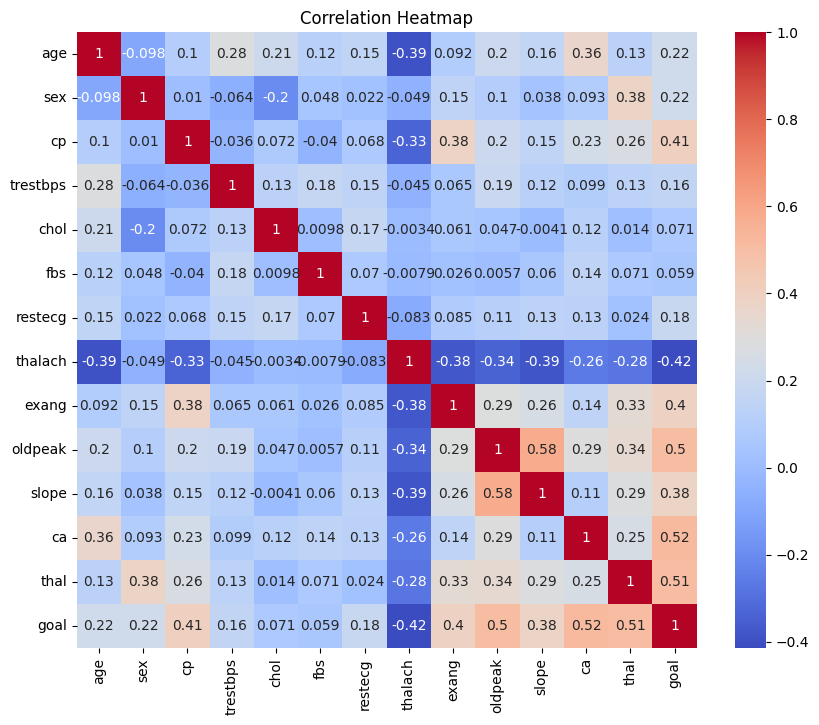

In [14]:
# Correlation matrix
numeric_data = data.select_dtypes(include=['number'])
corr = numeric_data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**TASK 2:**

Train at least three types of classifiers to diagnose heart disease based on the available data and compare them visually in a grouped bar chart with regard to accuracy, sensitivity, and specificity. Create a confusion matrix for each classifier and plot them as a heatmap.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve, auc

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Task 2: Multi-class classification (goal 0-4)
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = data[feature_names]
y = data['goal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# Train classifiers (simplified: using Decision Tree instead of Random Forest)
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=1)
}

In [30]:
# Metrics: Accuracy, Specificity, Sensitivity
metrics = {'Accuracy': [], 'Specificity (Macro)': [], 'Sensitivity (Macro Recall)': []}
cms = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    sens = report['macro avg']['recall']
    cm = confusion_matrix(y_test, y_pred)
    spec = []
    for i in range(len(report) - 3):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    avg_spec = np.mean(spec)

    metrics['Accuracy'].append(acc)
    metrics['Specificity (Macro)'].append(avg_spec)
    metrics['Sensitivity (Macro Recall)'].append(sens)
    cms[name] = cm

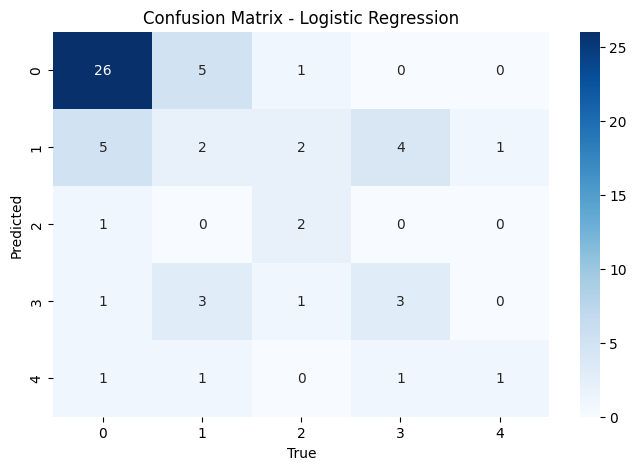

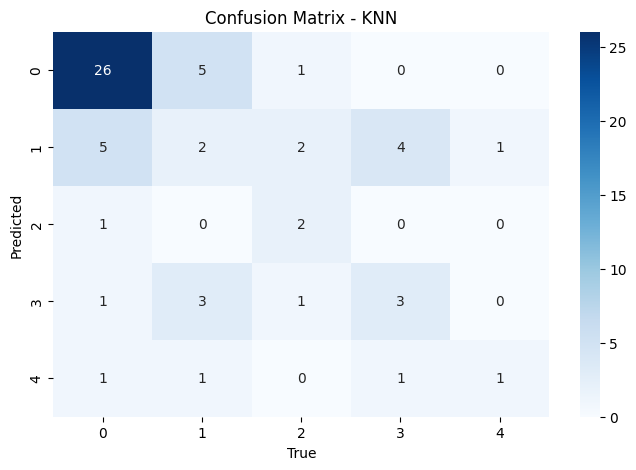

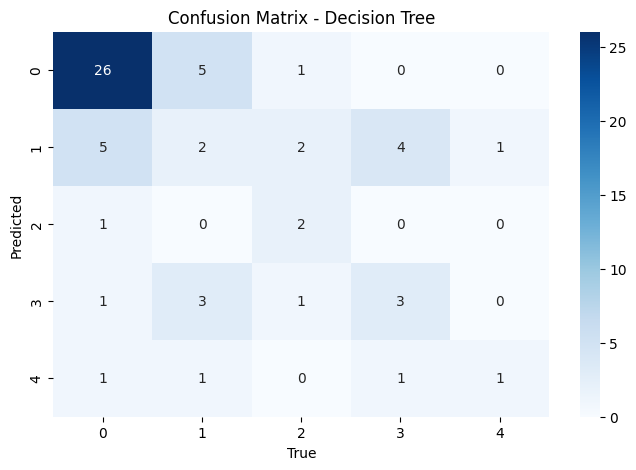

In [31]:
# Confusion matrix heatmap
for name, clf in classifiers.items():

  plt.figure(figsize=(8, 5))
  sns.heatmap(cm.T, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion Matrix - {name}')
  plt.xlabel('True')
  plt.ylabel('Predicted')
  plt.show()


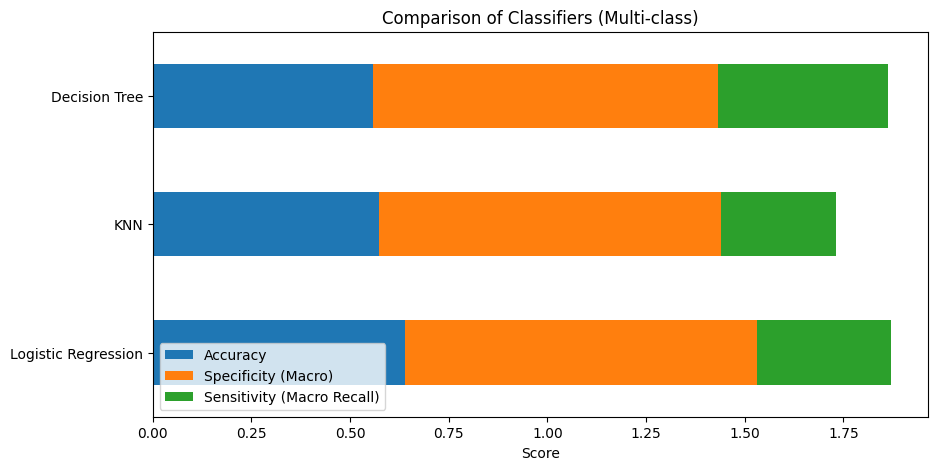

In [32]:
# Grouped bar chart
metrics_df = pd.DataFrame(metrics, index=classifiers.keys())
metrics_df.plot(kind='barh', stacked=True, figsize=(10,5))
plt.title('Comparison of Classifiers (Multi-class)')
plt.xlabel('Score')
plt.show()

TASK 3:

Repeat the steps of the previous task, using as class labels only “heart disease vs. no heart disease” . Analyze the implications of this change. Does it make sense?

In [33]:
from sklearn.metrics import roc_curve

data['binary_goal'] = data['goal'].apply(lambda x: 0 if x == 0 else 1)
y_binary = data['binary_goal']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=1)
X_train_b = scaler.fit_transform(X_train_b)
X_test_b = scaler.transform(X_test_b)

In [34]:
# Classifiers for binary
metrics_binary = {'Accuracy': [], 'Specificity': [], 'Sensitivity': []}
cms_binary = {}
probas = {}
for name, clf in classifiers.items():
    clf.fit(X_train_b, y_train_b)
    y_pred_b = clf.predict(X_test_b)
    acc = accuracy_score(y_test_b, y_pred_b)
    cm = confusion_matrix(y_test_b, y_pred_b)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    metrics_binary['Accuracy'].append(acc)
    metrics_binary['Specificity'].append(spec)
    metrics_binary['Sensitivity'].append(sens)
    cms_binary[name] = cm

In [35]:
for name, clf in classifiers.items():
  if hasattr(clf, 'predict_proba'):
      probas[name] = clf.predict_proba(X_test_b)[:, 1]
  else:
      probas[name] = clf.decision_function(X_test_b)  # For KNN, but KNN has predict_proba

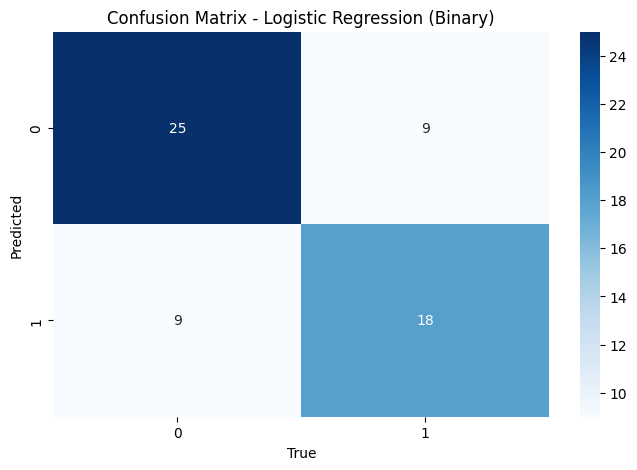

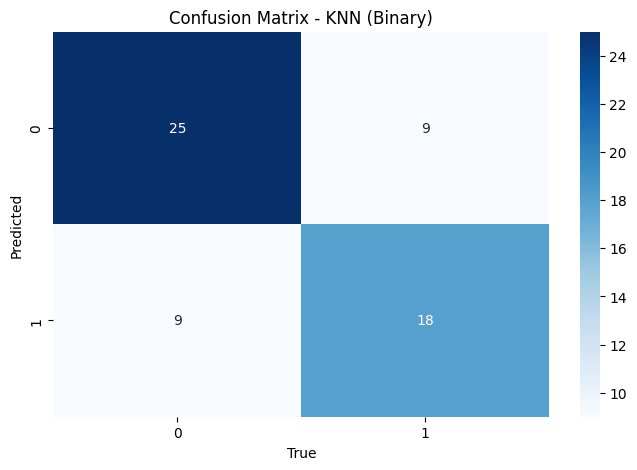

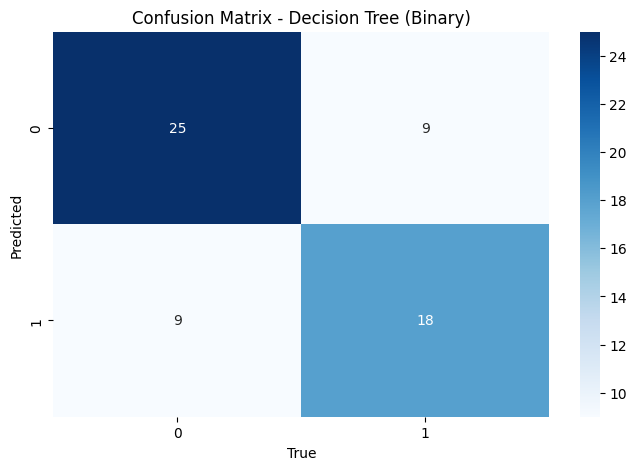

In [36]:
# Confusion matrix heatmaps for binary classification
for name, clf in classifiers.items():
  plt.figure(figsize=(8, 5))
  sns.heatmap(cm.T, annot=True, fmt='d', cmap='Blues')
  plt.title(f'Confusion Matrix - {name} (Binary)')
  plt.xlabel('True')
  plt.ylabel('Predicted')
  plt.show()


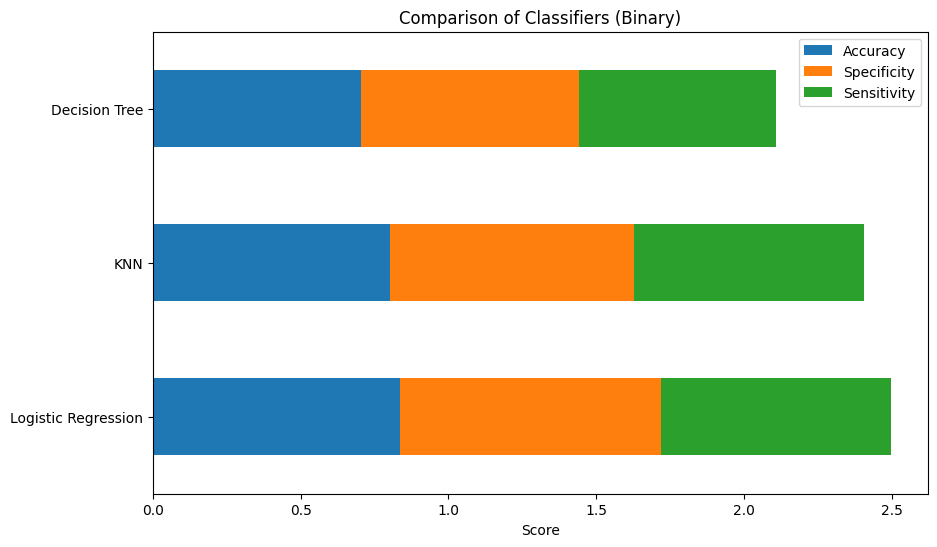

In [25]:
# Grouped bar chart for binary classification
metrics_b_df = pd.DataFrame(metrics_binary, index=classifiers.keys())
metrics_b_df.plot(kind='barh', stacked=True, figsize=(10,6))
plt.title('Comparison of Classifiers (Binary)')
plt.xlabel('Score')
plt.show()


Task 4: ROC curves for binary

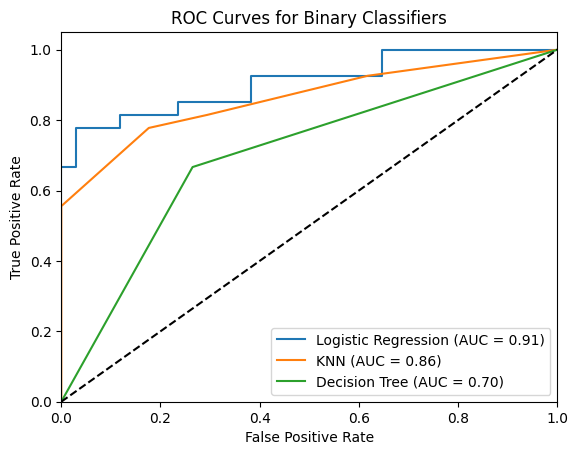

In [37]:
plt.figure()
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test_b, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Binary Classifiers')
plt.legend(loc='lower right')
plt.show()